## Populations of the dressed states
Comparision of the dressed states population @ SS: with, and without Thz coupling.

### Notes:
- I have surpressed the "optical" cavity used as a sensor, as the spectrum is not required in this calculation, with the aim to speed it up.
- I assumed the known result $\braket{+|\rho_{SS}|+} = \braket{-|\rho_{SS}|-} = \frac{1}{2}$ for a single qubit, instead of calculating explicitely.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

Parameters

In [15]:
kappa_b = 1 #decay en la cav de THz
gamma = 1e-4 * kappa_b # decay en el qubit

chi =  0.1*kappa_b      # acoplo qubit con THz

Omega = 200 * kappa_b  # en uds de kappa_b y 1e6 veces mayor que gamma

Nb = 3         # segunda cavidad

w_THz_list = np.linspace(0, 400, 90)

Operators

In [16]:
sx = tensor(sigmax(), qeye(Nb))
sz = tensor(sigmaz(), qeye(Nb))
sm = tensor(sigmam(), qeye(Nb))

b = tensor(qeye(2), destroy(Nb))
b_dag = b.dag()

# Disipadores
D_with = [
    np.sqrt(gamma) * sm,
    np.sqrt(kappa_b) * b
]

### Calculations
1. Definition of $\ket{\pm}$ as the eigenstates of the  single qubit hamiltonian: $H_q = \frac{\Omega}{2}\sigma_x + \Delta_q\sigma_z$ (where $\Delta_q= 0$ in this case)
2. Obtention of the density matrix @ steady state
3. Calcuaktion of the expectation value of the dressed states projectors

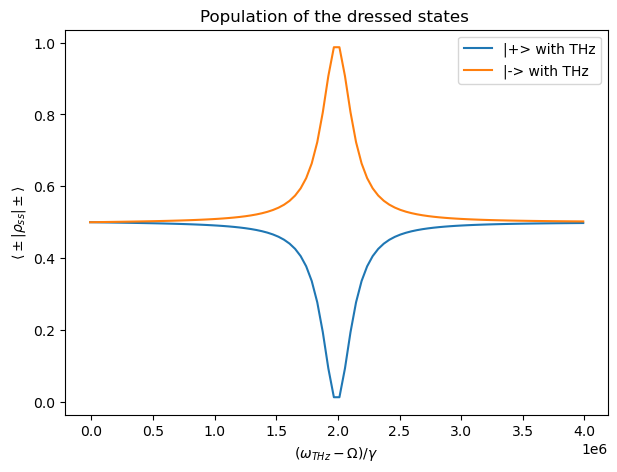

In [17]:
# vectors where we store the population @ each w_b
pops_plus = []
pops_minus = []

x_axis = w_THz_list - np.ones(len(w_THz_list))

for w_b in w_THz_list:

    Delta_q = 0
    H_qubit = (Omega/2)*sigmax() + Delta_q*sigmaz()
    eigvals, eigstates = H_qubit.eigenstates()

    plus_state = eigstates[1]  # mayor energía
    minus_state = eigstates[0] #menor energía

    # extender al espacio total
    plus = tensor(eigstates[1], qeye(Nb))
    P_plus = plus * plus.dag()

    minus = tensor(eigstates[0], qeye(Nb))
    P_minus = minus * minus.dag()

    H = (Omega/2)*sx + Delta_q * sz + w_b * b_dag * b + chi * (sz + 1) * (b + b_dag)

    rho_ss_with = steadystate(H, D_with)
    pop_plus= expect(P_plus, rho_ss_with)
    pop_minus = expect(P_minus, rho_ss_with)

    pops_minus.append(pop_minus)
    pops_plus.append(pop_plus)

# =========================
# Gráfica
# =========================
plt.figure(figsize=(7,5))

plt.plot(x_axis/gamma, pops_plus, label="|+> with THz")
plt.plot(x_axis/gamma, pops_minus, label="|-> with THz")

plt.xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")
plt.ylabel(r"$\langle \pm | \rho_{ss} | \pm \rangle$")
plt.title("Population of the dressed states ")

plt.legend()


plt.show()